[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter14_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 14: Deep Learning and Time-Series Foundation Models

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza — Bucharest University of Economic Studies.*

- **Part A**: derivations (gradients as VAR impulse responses, the LSTM cell state as an AR(1), mean scaling, VaR and ES from a grid and a GPD tail, the power of Kupiec, what QLIKE elicits).
- **Part B**: inference on the forecasts of Chapter 14: returns (Clark–West, SPA, Romano–Wolf), realised volatility, tail risk, seeds, leakage, calibration (PIT, CRPS), conformal recalibration, a pre/post-release test.
- **Part C**: can a zero-shot foundation model replace GARCH for the daily VaR 1% and ES 2.5% of the BET index?
- **[Solved]** problems are fully worked out (code and output); **[Proposed]** problems have an empty cell for you: their solutions are discussed in the seminar.
- Models: A2 after A1; A4 after A3; A6 and A7 after A5; A9 after A8; B2 after B1; B4, B8, B11 after B3; B6 after B5; B10 after B5 and B9.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_14'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


> The solutions are discussed in the seminar.

In [ ]:
import os
import sys
import json
import time
import subprocess
for pkg, mod in (('arch', 'arch'), ('chronos-forecasting', 'chronos'), ('timesfm', 'timesfm')):
    try:
        __import__(mod)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import torch
import warnings
warnings.filterwarnings('ignore')

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

# nume -> (simbol, data de start); indici si cripto: pretul de inchidere
SOURCES = {'sp500': ('GSPC.INDX', '1990-01-01'), 'btc': ('BTC-USD.CC', '2014-09-17'), 'bet': ('BET', '1997-09-19')}
LABELS = {'sp500': 'S&P 500', 'btc': 'Bitcoin', 'bet': 'BET'}
ASSETS = list(SOURCES)
TEST_FROM = {'sp500': '2016-01-01', 'btc': '2019-01-01', 'bet': '2016-01-01'}
POST_FROM = '2025-11-03'   # dupa publicarea ponderilor tuturor celor trei modele fundationale
CTX = 512                  # lungimea contextului (observatii) pentru modelele fundationale
W = 1000                   # fereastra de estimare pentru HS, GARCH-t, FHS
REFIT = 20                 # reestimarea parametrilor GARCH la fiecare 20 de zile
A_VAR, A_ES = 0.01, 0.025  # VaR 1%, ES 2.5%
FM_NAMES = {'chronos2': 'Chronos-2', 'bolt': 'Chronos-Bolt', 'timesfm': 'TimesFM-2.5'}
FM_REPO = {'chronos2': 'amazon/chronos-2', 'bolt': 'amazon/chronos-bolt-small',
           'timesfm': 'google/timesfm-2.5-200m-pytorch'}
C2_LEVELS = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,
             0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
DEC_LEVELS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


# =============================================================================
# DATE
# =============================================================================
def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def load_returns(name):
    """Randamente log zilnice in %, pe calendarul propriu al seriei."""
    symbol, start = SOURCES[name]
    p = read_market(symbol)['close'].loc[start:]
    p = p[p > 0].dropna()
    return (100 * np.log(p).diff()).dropna().rename(LABELS[name])


def load_rv():
    """Varianta realizata zilnica a SPY (sesiunea regulata, randamente la 5 minute, %^2)
    si randamentul zilnic close-to-close al SPY (%), pe aceleasi zile."""
    fname = 'intraday/SPY.US_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    d = pd.read_csv(path if os.path.exists(path) else REPO_RAW + fname, parse_dates=['datetime_utc'])
    d['day'] = d['datetime_utc'].dt.normalize()
    d['r'] = 100 * np.log(d['close']).groupby(d['day']).diff()
    rv = (d['r'] ** 2).groupby(d['day']).sum()
    n = d.groupby('day').size()
    rv = rv[n >= 70]                       # fara zilele cu program redus
    rv.index = rv.index.tz_localize(None) if rv.index.tz is not None else rv.index
    rv.name = 'RV'
    return rv


def load_spy_daily():
    """Randamentele zilnice close-to-close ale SPY (%, pret ajustat)."""
    p = read_market('SPY.US')['adjusted_close']
    return (100 * np.log(p).diff()).dropna().rename('SPY')


# =============================================================================
# MODELE FUNDATIONALE (zero-shot)
# =============================================================================
_FM = {}


def load_fm(name):
    """Incarca o singura data modelul fundational (CPU)."""
    if name in _FM:
        return _FM[name]
    import torch
    if name in ('chronos2', 'bolt'):
        from chronos import BaseChronosPipeline
        _FM[name] = BaseChronosPipeline.from_pretrained(FM_REPO[name], device_map='cpu', torch_dtype=torch.float32)
    elif name == 'timesfm':
        import timesfm
        m = timesfm.TimesFM_2p5_200M_torch.from_pretrained(FM_REPO[name])
        m.compile(timesfm.ForecastConfig(max_context=1024, max_horizon=128, normalize_inputs=True,
                                         use_continuous_quantile_head=True, force_flip_invariance=True,
                                         infer_is_positive=False, fix_quantile_crossing=True,
                                         per_core_batch_size=128))
        _FM[name] = m
    else:
        raise ValueError(name)
    return _FM[name]


def fm_forecast(name, contexts, batch=256):
    """Prognoza la o zi pentru o lista de contexte (np.array 1D).
    Rezultat: (levels, Q, point), Q = matrice n x len(levels) de cuantile, point = prognoza punctuala
    (mediana pentru Chronos, media pentru TimesFM)."""
    import torch
    m = load_fm(name)
    Qs, P = [], []
    for i in range(0, len(contexts), batch):
        cb = [np.asarray(c, dtype='float32') for c in contexts[i:i + batch]]
        if name == 'chronos2':
            q, _ = m.predict_quantiles([torch.tensor(c)[None, :] for c in cb], prediction_length=1,
                                       quantile_levels=C2_LEVELS)
            Q = np.stack([qi[0, 0].numpy() for qi in q])
            Qs.append(Q)
            P.append(Q[:, C2_LEVELS.index(0.5)])
        elif name == 'bolt':
            L = max(len(c) for c in cb)
            x = torch.full((len(cb), L), float('nan'))
            for j, c in enumerate(cb):
                x[j, L - len(c):] = torch.tensor(c)
            q, _ = m.predict_quantiles(x, prediction_length=1, quantile_levels=DEC_LEVELS)
            Q = q[:, 0, :].numpy()
            Qs.append(Q)
            P.append(Q[:, DEC_LEVELS.index(0.5)])
        else:
            pf, qf = m.forecast(horizon=1, inputs=cb)
            Qs.append(np.asarray(qf)[:, 0, 1:10])
            P.append(np.asarray(pf)[:, 0])
    levels = C2_LEVELS if name == 'chronos2' else DEC_LEVELS
    return levels, np.vstack(Qs), np.concatenate(P)


def contexts_at(x, origins, ctx=CTX):
    """Contextul x[t-ctx:t] pentru fiecare origine t (pozitie in x)."""
    x = np.asarray(x, float)
    return [x[max(0, t - ctx):t] for t in origins]


def quantile_at(levels, Q, u):
    """Cuantila de nivel u prin interpolare liniara intre nivelurile disponibile; in afara grilei:
    valoarea de la capat (modelul nu ofera cuantile mai extreme)."""
    lv = np.asarray(levels)
    return np.array([np.interp(u, lv, row) for row in Q])


def grid_mean(levels, Q, g=lambda v: v):
    """Aproximarea E[g(Y)] = integrala din g(q_u) pe [0, 1], cu q_u liniar intre niveluri si constant
    in afara grilei (subestimeaza cozile)."""
    lv = np.r_[0.0, levels, 1.0]
    G = g(np.column_stack([Q[:, :1], Q, Q[:, -1:]]))
    return np.trapezoid(G, lv, axis=1)


def es_from_grid(levels, Q, a=A_ES, n=200):
    """ES_a = -(1/a) * integrala_0^a q_u du, pe grila modelului (sub cel mai mic nivel: constant)."""
    u = (np.arange(n) + 0.5) / n * a
    return -np.mean(np.column_stack([quantile_at(levels, Q, ui) for ui in u]), axis=1)


# =============================================================================
# MODELE DE BAZA PENTRU RANDAMENTE
# =============================================================================
def hist_mean(r, origins):
    x = np.asarray(r, float)
    cs = np.r_[0, np.cumsum(x)]
    return np.array([cs[t] / t for t in origins])


def ar1(r, origins, w=W):
    """AR(1) estimat prin MCO pe fereastra mobila de w observatii."""
    x = np.asarray(r, float)
    out = []
    for t in origins:
        y = x[max(0, t - w):t]
        X = np.column_stack([np.ones(len(y) - 1), y[:-1]])
        b = np.linalg.lstsq(X, y[1:], rcond=None)[0]
        out.append(b[0] + b[1] * y[-1])
    return np.array(out)


def garch_t(r, origins, w=W, refit=REFIT):
    """GARCH(1,1) cu inovatii Student-t (medie constanta), fereastra mobila de w observatii,
    parametrii reestimati la fiecare `refit` zile. Rezultat: DataFrame cu mu, sigma, nu la fiecare origine
    si reziduurile standardizate din fereastra (pentru FHS)."""
    from arch import arch_model
    x = np.asarray(r, float)
    rows, Z = [], []
    par = None
    for k, t in enumerate(origins):
        y = x[t - w:t]
        if k % refit == 0 or par is None:
            res = arch_model(y, mean='Constant', vol='GARCH', p=1, q=1, dist='t', rescale=False).fit(
                disp='off', show_warning=False)
            par = res.params.values        # mu, omega, alpha, beta, nu
        mu, om, al, be, nu = par
        e = y - mu
        s2 = np.empty(len(y) + 1)
        s2[0] = e.var()
        for i in range(len(y)):
            s2[i + 1] = om + al * e[i] ** 2 + be * s2[i]
        rows.append((mu, np.sqrt(s2[-1]), nu))
        Z.append(e / np.sqrt(s2[:-1]))
    return pd.DataFrame(rows, columns=['mu', 'sigma', 'nu']), Z


def t_std_q(nu, a):
    """Cuantila de nivel a a distributiei Student-t standardizate (dispersie 1)."""
    return stats.t.ppf(a, nu) * np.sqrt((nu - 2) / nu)


def t_std_es(nu, a):
    """ES_a (pozitiv) al distributiei Student-t standardizate: -E[Z | Z <= q_a]."""
    q = stats.t.ppf(a, nu)
    return stats.t.pdf(q, nu) / a * (nu + q ** 2) / (nu - 1) * np.sqrt((nu - 2) / nu)


def emp_var_es(z, a_var=A_VAR, a_es=A_ES):
    """VaR si ES empirice (pozitive) dintr-un esantion: VaR_a = -q_a, ES_a = -media cozii de probabilitate a."""
    z = np.sort(np.asarray(z))
    n = len(z)
    k = int(np.ceil(a_es * n))
    return -np.quantile(z, a_var), -np.quantile(z, a_es), -z[:k].mean()


def risk_table(r, origins, fm_sigma=None):
    """VaR 1%, VaR 2.5%, ES 2.5% la o zi pentru HS, GARCH-t, FHS si (optional) FHS filtrat cu volatilitatea
    unui model fundational: z = r / sigma_FM pe fereastra de W zile."""
    x = np.asarray(r, float)
    g, Z = garch_t(r, origins)
    out = {}
    hs = np.array([emp_var_es(x[t - W:t]) for t in origins])
    out['HS'] = hs
    gt = np.column_stack([-(g.mu + g.sigma * t_std_q(g.nu, A_VAR)), -(g.mu + g.sigma * t_std_q(g.nu, A_ES)),
                          -g.mu + g.sigma * t_std_es(g.nu, A_ES)])
    out['GARCH-t'] = gt
    fhs = np.array([emp_var_es(z) for z in Z])
    out['FHS'] = np.column_stack([-g.mu.values + g.sigma.values * fhs[:, 0],
                                  -g.mu.values + g.sigma.values * fhs[:, 1],
                                  -g.mu.values + g.sigma.values * fhs[:, 2]])
    if fm_sigma is not None:
        for nm, sig in fm_sigma.items():   # sig: serie aliniata cu x (NaN unde lipseste)
            s = np.asarray(sig, float)
            rows = []
            for t in origins:
                zz = x[t - W:t] / s[t - W:t]
                rows.append(s[t] * np.array(emp_var_es(zz[np.isfinite(zz)])))
            out[nm] = np.array(rows)
    return {k: pd.DataFrame(v, columns=['VaR1', 'VaR2.5', 'ES2.5']) for k, v in out.items()}


# =============================================================================
# VOLATILITATE REALIZATA: HAR
# =============================================================================
def har_design(y):
    """Regresorii HAR: nivelul de ieri, media pe 5 zile si media pe 22 de zile."""
    s = pd.Series(y)
    d = s.shift(1)
    wk = s.rolling(5).mean().shift(1)
    mo = s.rolling(22).mean().shift(1)
    return np.column_stack([np.ones(len(s)), d, wk, mo])


def har(rv, origins, w=500, log=False):
    """Prognoza HAR la o zi (MCO pe fereastra mobila de w zile). log=True: HAR pe log RV,
    cu corectia exp(s^2/2) pentru media."""
    y = np.log(np.asarray(rv, float)) if log else np.asarray(rv, float)
    X = har_design(y)
    out = []
    for t in origins:
        idx = np.arange(max(22, t - w), t)
        b, *_ = np.linalg.lstsq(X[idx], y[idx], rcond=None)
        f = X[t] @ b
        if log:
            s2 = np.var(y[idx] - X[idx] @ b, ddof=4)
            f = np.exp(f + s2 / 2)
        out.append(f)
    return np.array(out)


# =============================================================================
# LSTM (PyTorch, CPU)
# =============================================================================
def make_windows(x, L):
    """Ferestre de lungime L ca intrari si valoarea urmatoare ca tinta."""
    x = np.asarray(x, float)
    idx = np.arange(L, len(x))
    return np.stack([x[i - L:i] for i in idx]), x[idx]


def train_lstm(X, y, hidden=16, epochs=300, lr=3e-3, seed=0, val_frac=0.2, patience=25, weight_decay=1e-4):
    """LSTM cu un strat (intrare univariata, lungime L) + strat liniar; MSE, Adam, oprire timpurie
    pe ultimele val_frac din esantion (ordinea in timp se pastreaza). Rezultat: (functie de prognoza, istoric)."""
    import torch
    import torch.nn as nn
    torch.manual_seed(seed)
    np.random.seed(seed)

    class Net(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(1, hidden, batch_first=True)
            self.out = nn.Linear(hidden, 1)

        def forward(self, z):
            h, _ = self.lstm(z.unsqueeze(-1))
            return self.out(h[:, -1]).squeeze(-1)

    n = len(y)
    nv = int(val_frac * n)
    Xt, yt = torch.tensor(X[:n - nv], dtype=torch.float32), torch.tensor(y[:n - nv], dtype=torch.float32)
    Xv, yv = torch.tensor(X[n - nv:], dtype=torch.float32), torch.tensor(y[n - nv:], dtype=torch.float32)
    net = Net()
    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    best, best_state, wait, hist = np.inf, None, 0, []
    for ep in range(epochs):
        net.train()
        perm = torch.randperm(len(yt))
        for i in range(0, len(yt), 256):
            b = perm[i:i + 256]
            opt.zero_grad()
            loss = ((net(Xt[b]) - yt[b]) ** 2).mean()
            loss.backward()
            opt.step()
        net.eval()
        with torch.no_grad():
            lt = float(((net(Xt) - yt) ** 2).mean())
            lv = float(((net(Xv) - yv) ** 2).mean())
        hist.append((lt, lv))
        if lv < best - 1e-7:
            best, wait = lv, 0
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    net.load_state_dict(best_state)
    net.eval()

    def predict(Xn):
        with torch.no_grad():
            return net(torch.tensor(np.asarray(Xn), dtype=torch.float32)).numpy()
    return predict, np.array(hist)


def lstm_param_count(d, h, torch_bias=True):
    """Numarul de parametri ai unui strat LSTM: 4 blocuri (3 porti + candidatul) x (h*d + h*h + h);
    PyTorch foloseste doi vectori de deplasare (b_ih, b_hh), deci 4 x (h*d + h*h + 2h)."""
    return 4 * (h * d + h * h + (2 if torch_bias else 1) * h)


# =============================================================================
# FUNCTII DE PIERDERE SI TESTE
# =============================================================================
def qlike(y, f):
    """QLIKE = y/f - log(y/f) - 1 (Patton, 2011): robusta la zgomotul aproximarii volatilitatii."""
    ratio = np.asarray(y) / np.asarray(f)
    return ratio - np.log(ratio) - 1


def pinball(r, q, a):
    """Pierderea cuantila pentru cuantila q de nivel a a randamentului r: (a - 1{r < q})(r - q)."""
    r, q = np.asarray(r), np.asarray(q)
    return (a - (r < q)) * (r - q)


def fz0(L, var, es, a=A_ES):
    """Pierderea FZ0 (Patton, Ziegel & Chen, 2019) pentru pierderi L = -r pozitive, VaR si ES > 0."""
    L, var, es = map(np.asarray, (L, var, es))
    return (L > var) * (L - var) / (a * es) + var / es + np.log(es) - 1


def kupiec(hits, p):
    """Testul POF al lui Kupiec: LR_uc ~ chi2(1)."""
    hits = np.asarray(hits, int)
    T, x = len(hits), hits.sum()
    ph = x / T
    ll0 = (T - x) * np.log(1 - p) + x * np.log(p)
    ll1 = (T - x) * np.log(1 - ph) + x * np.log(ph) if 0 < x < T else 0.0
    lr = -2 * (ll0 - ll1)
    return dict(T=int(T), x=int(x), rate=float(ph), LR=float(lr), p=float(stats.chi2.sf(lr, 1)))


def christoffersen(hits, p):
    """Testul de independenta (lant Markov de ordinul 1) si testul acoperirii conditionate."""
    h = np.asarray(hits, int)
    a, b = h[:-1], h[1:]
    n00, n01 = np.sum((a == 0) & (b == 0)), np.sum((a == 0) & (b == 1))
    n10, n11 = np.sum((a == 1) & (b == 0)), np.sum((a == 1) & (b == 1))

    def xlogy(n, q):
        return n * np.log(q) if n > 0 else 0.0
    pi01 = n01 / max(n00 + n01, 1)
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)
    l_ind = xlogy(n00, 1 - pi01) + xlogy(n01, pi01) + xlogy(n10, 1 - pi11) + xlogy(n11, pi11)
    l_0 = xlogy(n00 + n10, 1 - pi) + xlogy(n01 + n11, pi)
    lr_ind = -2 * (l_0 - l_ind)
    lr_uc = kupiec(h, p)['LR']
    return dict(n11=int(n11), pi01=float(pi01), pi11=float(pi11), LR_ind=float(lr_ind),
                p_ind=float(stats.chi2.sf(lr_ind, 1)), LR_cc=float(lr_uc + lr_ind),
                p_cc=float(stats.chi2.sf(lr_uc + lr_ind, 2)))


def nw_var(d, lags=None):
    """Varianta pe termen lung (Newey-West, nucleu Bartlett)."""
    d = np.asarray(d, float) - np.mean(d)
    T = len(d)
    if lags is None:
        lags = int(np.floor(4 * (T / 100) ** (2 / 9)))
    v = np.mean(d ** 2)
    for j in range(1, lags + 1):
        v += 2 * (1 - j / (lags + 1)) * np.mean(d[j:] * d[:-j])
    return v


def diebold_mariano(la, lb, lags=None):
    """DM = media(d) / sqrt(LRV/T), d = la - lb; negativ => A are pierderea medie mai mica."""
    d = np.asarray(la, float) - np.asarray(lb, float)
    dm = d.mean() / np.sqrt(nw_var(d, lags) / len(d))
    return dict(dbar=float(d.mean()), DM=float(dm), p=float(2 * stats.norm.sf(abs(dm))))


def mcs(losses, B=1000, block=10, seed=2):
    """Multimea de modele de incredere (Hansen, Lunde & Nason, 2011), statistica T_max,
    bootstrap circular pe blocuri. losses: DataFrame T x m. Rezultat: valorile p ale MCS."""
    rng = np.random.default_rng(seed)
    X = losses.values
    T, m = X.shape
    nb = int(np.ceil(T / block))
    idx = (rng.integers(0, T, (B, nb))[:, :, None] + np.arange(block)) % T
    idx = idx.reshape(B, -1)[:, :T]
    Lbar = X.mean(0)
    Lb = np.stack([X[i].mean(0) for i in idx])
    alive = list(range(m))
    pvals, p_run = {}, 0.0
    while len(alive) > 1:
        a = np.array(alive)
        d = Lbar[a] - Lbar[a].mean()
        db = Lb[:, a] - Lb[:, a].mean(1, keepdims=True)
        se = np.sqrt(np.mean((db - d) ** 2, axis=0))
        t = d / se
        tb = ((db - d) / se).max(1)
        p = float(np.mean(tb >= t.max()))
        p_run = max(p_run, p)
        worst = a[np.argmax(t)]
        pvals[losses.columns[worst]] = p_run
        alive.remove(worst)
    pvals[losses.columns[alive[0]]] = 1.0
    return pd.Series(pvals)[losses.columns]


def r2_oos(y, f, bench=None):
    """R^2 in afara esantionului fata de un reper (implicit: prognoza zero)."""
    y, f = np.asarray(y), np.asarray(f)
    b = np.zeros_like(y) if bench is None else np.asarray(bench)
    return 1 - np.sum((y - f) ** 2) / np.sum((y - b) ** 2)


def block_bootstrap_ci(stat, arrays, B=2000, block=20, seed=0, level=0.95):
    """Interval bootstrap pe blocuri circulare (percentile) pentru o statistica a mai multor serii aliniate."""
    rng = np.random.default_rng(seed)
    T = len(arrays[0])
    nb = int(np.ceil(T / block))
    vals = []
    for _ in range(B):
        idx = ((rng.integers(0, T, nb)[:, None] + np.arange(block)) % T).ravel()[:T]
        vals.append(stat(*[np.asarray(a)[idx] for a in arrays]))
    lo, hi = np.quantile(vals, [(1 - level) / 2, 1 - (1 - level) / 2])
    return float(lo), float(hi)


def sign_test(y, f):
    """Rata semnelor corecte si valoarea p binomiala bilaterala (H0: 50%)."""
    y, f = np.asarray(y), np.asarray(f)
    keep = (y != 0) & (f != 0)
    k = int(np.sum(np.sign(y[keep]) == np.sign(f[keep])))
    n = int(keep.sum())
    return dict(rate=k / n, n=n, p=float(stats.binomtest(k, n, 0.5).pvalue))

In [ ]:
# Stil standard MFM: transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Crimson = '#DC3545'
Teal = '#17A2B8'
Magenta = '#D63384'
Brown = '#795548'
Gray = '#7F7F7F'          # doar linii de referinta
LightGray = '#DADADA'     # doar benzi
PV_CMAP = LinearSegmentedColormap.from_list('pv', [IDAred, '#F4B6B6', '#FFFFFF', '#BFD8BF', Forest])

RET_MODELS = {'hist': 'Historical mean', 'ar1': 'AR(1)', 'lstm': 'LSTM (5 seeds)',
              'chronos2_point': 'Chronos-2', 'bolt_point': 'Chronos-Bolt', 'timesfm_point': 'TimesFM-2.5'}
RET_COL = {'hist': Amber, 'ar1': Purple, 'lstm': Forest, 'chronos2_point': IDAred, 'bolt_point': Orange,
           'timesfm_point': MainBlue}
RV_MODELS = ['RW', 'HAR', 'logHAR', 'GARCH-t', 'LSTM', 'Chronos-2', 'Chronos-Bolt', 'TimesFM-2.5']
RV_LBL = {'RW': 'Random walk', 'HAR': 'HAR', 'logHAR': 'log-HAR', 'GARCH-t': 'GARCH-t', 'LSTM': 'LSTM',
          'Chronos-2': 'Chronos-2', 'Chronos-Bolt': 'Chronos-Bolt', 'TimesFM-2.5': 'TimesFM-2.5'}
RV_COL = {'RW': Amber, 'HAR': Brown, 'logHAR': Purple, 'GARCH-t': Magenta, 'LSTM': Forest, 'Chronos-2': IDAred,
          'Chronos-Bolt': Orange, 'TimesFM-2.5': MainBlue}
RISK_MODELS = ['HS', 'GARCH-t', 'FHS', 'C2-raw', 'C2-FHS', 'TFM-FHS']
RISK_LBL = {'HS': 'HS', 'GARCH-t': 'GARCH-t', 'FHS': 'FHS', 'C2-raw': 'Chronos-2 quantiles',
            'C2-FHS': 'FHS + Chronos-2 volatility', 'TFM-FHS': 'FHS + TimesFM volatility',
            'bolt-raw': 'Chronos-Bolt quantiles', 'timesfm-raw': 'TimesFM quantiles'}
RISK_COL = {'HS': Teal, 'GARCH-t': MainBlue, 'FHS': Forest, 'C2-raw': IDAred, 'C2-FHS': Orange,
            'TFM-FHS': Purple, 'bolt-raw': Amber, 'timesfm-raw': Magenta}


RES = {}
FC_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_14/'
FC_DIR = next((d for d in ('.', '..', 'Quantlets/Ch_14', '../Quantlets/Ch_14', '../../Quantlets/Ch_14')
               if os.path.exists(os.path.join(d, 'ch14_rv.csv'))), None)


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def load_csv(name):
    """Tabelul de prognoze ch14_*.csv (produs de run_forecasts), local sau din repository."""
    path = os.path.join(FC_DIR, name) if FC_DIR else FC_RAW + name
    return pd.read_csv(path, index_col=0, parse_dates=True)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0):
    """O singura legenda pentru toata figura, sub panouri."""
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)

RET_MODELS = {'hist': 'Historical mean', 'ar1': 'AR(1)', 'lstm': 'LSTM (5 seeds)', 'chronos2_point': 'Chronos-2', 'bolt_point': 'Chronos-Bolt', 'timesfm_point': 'TimesFM-2.5'}
RET_COL = {'hist': '#B5853F', 'ar1': '#8E44AD', 'lstm': '#2E7D32', 'chronos2_point': '#CD0000', 'bolt_point': '#E67E22', 'timesfm_point': '#1A3A6E'}
RV_MODELS = ['RW', 'HAR', 'logHAR', 'GARCH-t', 'LSTM', 'Chronos-2', 'Chronos-Bolt', 'TimesFM-2.5']
RV_LBL = {'RW': 'Random walk', 'HAR': 'HAR', 'logHAR': 'log-HAR', 'GARCH-t': 'GARCH-t', 'LSTM': 'LSTM', 'Chronos-2': 'Chronos-2', 'Chronos-Bolt': 'Chronos-Bolt', 'TimesFM-2.5': 'TimesFM-2.5'}
RV_COL = {'RW': '#B5853F', 'HAR': '#795548', 'logHAR': '#8E44AD', 'GARCH-t': '#D63384', 'LSTM': '#2E7D32', 'Chronos-2': '#CD0000', 'Chronos-Bolt': '#E67E22', 'TimesFM-2.5': '#1A3A6E'}
RISK_MODELS = ['HS', 'GARCH-t', 'FHS', 'C2-raw', 'C2-FHS', 'TFM-FHS']
RISK_LBL = {'HS': 'HS', 'GARCH-t': 'GARCH-t', 'FHS': 'FHS', 'C2-raw': 'Chronos-2 quantiles', 'C2-FHS': 'FHS + Chronos-2 volatility', 'TFM-FHS': 'FHS + TimesFM volatility', 'bolt-raw': 'Chronos-Bolt quantiles', 'timesfm-raw': 'TimesFM quantiles'}
RISK_COL = {'HS': '#17A2B8', 'GARCH-t': '#1A3A6E', 'FHS': '#2E7D32', 'C2-raw': '#CD0000', 'C2-FHS': '#E67E22', 'TFM-FHS': '#8E44AD', 'bolt-raw': '#B5853F', 'timesfm-raw': '#D63384'}


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

In [ ]:
SEEDS = [0, 1, 2, 3, 4]
L_RET = 20
HERE = '.'


def tick(msg, t0=[time.time()]):
    print(f'[{time.time() - t0[0]:7.0f}s] {msg}', flush=True)


def returns_block(name):
    r = load_returns(name)
    x = r.values
    t0 = r.index.searchsorted(pd.Timestamp(TEST_FROM[name]))
    org = np.arange(t0, len(r))
    out = pd.DataFrame({'y': x[org]}, index=r.index[org])
    out['hist'] = hist_mean(x, org)
    out['ar1'] = ar1(x, org)
    # LSTM: antrenat o singura data pe datele dinainte de perioada de test (standardizare cu statistici de antrenare)
    tr = x[max(0, t0 - 4000):t0]
    mu, sd = tr.mean(), tr.std()
    Xtr, ytr = make_windows((tr - mu) / sd, L_RET)
    Xte = np.stack([(x[t - L_RET:t] - mu) / sd for t in org])
    preds = []
    for s in SEEDS:
        f, hist = train_lstm(Xtr, ytr, hidden=16, seed=s)
        preds.append(mu + sd * f(Xte))
        pd.DataFrame(hist, columns=['train', 'val']).to_csv(os.path.join(HERE, f'ch14_lstm_hist_{name}_s{s}.csv'))
    for s, p in zip(SEEDS, preds):
        out[f'lstm_s{s}'] = p
    out['lstm'] = np.mean(preds, axis=0)
    tick(f'{name}: baselines + LSTM')
    ctx = contexts_at(x, org)
    for fm in ('chronos2', 'bolt', 'timesfm'):
        lv, Q, P = fm_forecast(fm, ctx)
        for j, u in enumerate(lv):
            out[f'{fm}_q{u:.2f}'] = Q[:, j]
        out[f'{fm}_point'] = P
        tick(f'{name}: {fm} on returns ({len(org)} origins)')
    return r, org, out


def risk_block(name, r, org, ret):
    x = r.values
    # volatilitatea prognozata de modelele fundationale pe |r| (context 512), pentru W zile inainte de test
    org_s = np.arange(org[0] - W, len(r))
    ctx = contexts_at(np.abs(x), org_s)
    sig = {}
    lv, Q, P = fm_forecast('chronos2', ctx)
    s = np.full(len(x), np.nan)
    s[org_s] = grid_mean(lv, Q)
    sig['C2-FHS'] = s
    tick(f'{name}: chronos2 on |r|')
    lv, Q, P = fm_forecast('timesfm', ctx)
    s = np.full(len(x), np.nan)
    s[org_s] = np.maximum(P, 1e-6)
    sig['TFM-FHS'] = s
    tick(f'{name}: timesfm on |r|')
    tabs = risk_table(x, org, fm_sigma=sig)
    out = pd.DataFrame(index=r.index[org])
    out['y'] = x[org]
    for k, t in tabs.items():
        for c in t.columns:
            out[f'{k}|{c}'] = t[c].values
    # cuantile directe (fara filtrare): Chronos-2 are nivelul 1%; Bolt si TimesFM au doar decile
    c2 = ret[[c for c in ret.columns if c.startswith('chronos2_q')]].values
    out['C2-raw|VaR1'] = -quantile_at(C2_LEVELS, c2, 0.01)
    out['C2-raw|VaR2.5'] = -quantile_at(C2_LEVELS, c2, 0.025)
    out['C2-raw|ES2.5'] = es_from_grid(C2_LEVELS, c2)
    for fm in ('bolt', 'timesfm'):
        Qd = ret[[c for c in ret.columns if c.startswith(fm + '_q')]].values
        out[f'{fm}-raw|VaR1'] = -quantile_at(DEC_LEVELS, Qd, 0.01)      # limitat la decila 10%
        out[f'{fm}-raw|VaR10'] = -Qd[:, 0]
    out['C2-raw|VaR10'] = -quantile_at(C2_LEVELS, c2, 0.10)
    # VaR 10% pentru HS si FHS (pentru comparatia cu decilele modelelor fundationale)
    gfit, Z = garch_t(x, org)
    out['HS|VaR10'] = [-np.quantile(x[t - W:t], 0.10) for t in org]
    out['FHS|VaR10'] = -(gfit.mu.values + gfit.sigma.values * np.array([np.quantile(z, 0.10) for z in Z]))
    for k, s in sig.items():
        out[f'{k}|sigma'] = s[org]
    tick(f'{name}: risk table')
    return out


def rv_block():
    rv = load_rv()
    spy = load_spy_daily()
    x = rv.values
    org = np.arange(500, len(rv))
    out = pd.DataFrame({'RV': x[org]}, index=rv.index[org])
    out['RW'] = x[org - 1]
    out['HAR'] = har(x, org)
    out['logHAR'] = har(x, org, log=True)
    # GARCH-t pe randamentele zilnice ale SPY, reexprimat in unitatile RV (raport pe ultimele 500 de zile)
    pos = spy.index.get_indexer(rv.index[org])
    gfit, _ = garch_t(spy.values, pos)
    r2 = pd.Series(spy.values ** 2, index=spy.index).reindex(rv.index).values
    c = np.array([np.nanmean(x[t - 500:t]) / np.nanmean(r2[t - 500:t]) for t in org])
    out['GARCH-t'] = c * gfit.sigma.values ** 2
    tick('rv: RW, HAR, GARCH-t')
    # LSTM pe log RV: fereastra mobila de 500 de zile, reantrenat la fiecare 125 de zile, 3 seminte
    lx = np.log(x)
    f_lstm = np.empty(len(org))
    for k0 in range(0, len(org), 125):
        t = org[k0]
        tr = lx[t - 500:t]
        mu, sd = tr.mean(), tr.std()
        Xtr, ytr = make_windows((tr - mu) / sd, 22)
        blk = org[k0:k0 + 125]
        Xte = np.stack([(lx[s - 22:s] - mu) / sd for s in blk])
        ps, s2 = [], []
        for sdd in (0, 1, 2):
            f, _ = train_lstm(Xtr, ytr, hidden=8, seed=sdd, epochs=200)
            ps.append(f(Xte))
            s2.append(np.var(ytr - f(Xtr)))
        f_lstm[k0:k0 + 125] = np.exp(mu + sd * np.mean(ps, axis=0) + sd ** 2 * np.mean(s2) / 2)
    out['LSTM'] = f_lstm
    tick('rv: LSTM')
    ctx = contexts_at(lx, org)
    for fm, col in (('chronos2', 'Chronos-2'), ('bolt', 'Chronos-Bolt'), ('timesfm', 'TimesFM-2.5')):
        lv, Q, P = fm_forecast(fm, ctx)
        out[col] = grid_mean(lv, Q, np.exp)
        out[col + '|median'] = np.exp(quantile_at(lv, Q, 0.5))
        tick(f'rv: {fm}')
    # sensibilitatea la lungimea contextului (Chronos-2)
    rows = {}
    for L in (32, 64, 128, 256, 512):
        lv, Q, P = fm_forecast('chronos2', contexts_at(lx, org, ctx=L))
        rows[L] = grid_mean(lv, Q, np.exp)
    ctxdf = pd.DataFrame(rows, index=rv.index[org])
    ctxdf.insert(0, 'RV', x[org])
    tick('rv: context lengths')
    return out, ctxdf

In [ ]:
# True: refacerea tuturor prognozelor la o zi (cateva minute pe CPU pentru fiecare activ, plus descarcarea
# modelelor); False: tabelele ch14_*.csv publicate in folderul Capitolului 14.
RECOMPUTE = False
if RECOMPUTE:
    rvo, ctxo = rv_block()
    rvo.to_csv('ch14_rv.csv'); ctxo.to_csv('ch14_ctx.csv')
    for a in ASSETS:
        r, org, ret = returns_block(a)
        ret.to_csv(f'ch14_returns_{a}.csv')
        risk_block(a, r, org, ret).to_csv(f'ch14_risk_{a}.csv')
    FC_DIR = '.'

## Part A — derivations

### A1. Vanishing gradients as VAR impulse responses [Solved]

- Linearised at $h^*=0$, the RNN is a VAR(1) with matrix $W$; the Jacobian $\partial h_T/\partial h_{T-k} = W^k$ is its impulse response.
- $W = \begin{pmatrix} 0.5 & 0.8 \\ 0 & 0.5 \end{pmatrix}$: spectral radius versus spectral norm.

In [6]:
Wm = np.array([[0.5, 0.8], [0.0, 0.5]])
print('rho(W) =', max(abs(np.linalg.eigvals(Wm))), ' ||W||_2 =', np.linalg.norm(Wm, 2))
for k in (1, 5, 20, 50):
    print(k, 'bound', np.linalg.norm(Wm, 2) ** k, ' ||W^k||_2 =', np.linalg.norm(np.linalg.matrix_power(Wm, k), 2))

rho(W) = 0.5  ||W||_2 = 1.040312423743285
1 bound 1.040312423743285  ||W^k||_2 = 1.040312423743285
5 bound 1.2184814586459825  ||W^k||_2 = 0.2538470508005519
20 bound 2.2043253750097773  ||W^k||_2 = 3.054735140026226e-05
50 bound 7.214217806875016  ||W^k||_2 = 7.106537407207468e-14


### A2. The LSTM cell state as an AR(1) [Proposed]

- Constant gates: $c_t = f c_{t-1} + i g_t$; half-lives; which $f$ matches the ACF of $|r_t|$ at lags 1 and 50, and what does it predict at lag 150? Model: A1.

In [ ]:
# Your code here


### A3. Mean scaling in Chronos: who moves the scale? [Solved]

- One day enters ($M$), one leaves ($x_{out}$): $s_{new} = s_{old} + (|M| - |x_{out}|)/C$. Four-day context $x = (0.8, -1.2, 0.4, 2.0)$.

In [8]:
x = np.array([0.8, -1.2, 0.4, 2.0])
s = np.abs(x).mean()
delta = 30 / 4092
z = x / s
print('s =', s, ' z =', z.round(4), ' bin index =', np.round((z + 15) / delta).astype(int))

s = 1.1  z = [ 0.7273 -1.0909  0.3636  1.8182]  bin index = [2145 1897 2096 2294]


### A4. A crash day in the context [Proposed]

- (a) Replace the last value by $-9.0$; (b) the S&P 500 on 16 March 2020 in a 512-day context. Model: A3.

In [ ]:
# Your code here


### A5. VaR 1% and ES 2.5% from a quantile grid [Solved]

- The last Chronos-2 forecast for the S&P 500: quantiles at 1% and 5%.

In [10]:
d = load_csv('ch14_returns_sp500.csv')
last = d.iloc[-1]
q01, q05 = last['chronos2_q0.01'], last['chronos2_q0.05']
q025 = q01 + (0.025 - 0.01) / 0.04 * (q05 - q01)
es = -(0.01 * q01 + 0.015 * (q01 + q025) / 2) / 0.025
print(d.index[-1].date(), 'VaR 1% =', -q01, ' VaR 2.5% =', -q025, ' ES 2.5% =', es)

2026-09-18 VaR 1% = 2.70354  VaR 2.5% = 2.21476125  ES 2.5% = 2.5569063749999996


### A6. Why the grid ES is a lower bound, and a GPD tail [Proposed]

- Prove the lower bound; derive $ES_\alpha = VaR_\alpha/(1-\xi) + (\beta - \xi u)/(1-\xi)$; fit a GPD to the S&P 500 losses of the last 1,000 days above their 95% quantile. Model: A5.

In [ ]:
# Your code here


### A7. A 'VaR 1%' from deciles [Proposed]

- Chronos-Bolt gives only $q_{0.1}, \dots, q_{0.9}$. Compare the clamped value $-q_{0.1}$ with a Normal extrapolation from $q_{0.1}$ and $q_{0.5}$. Model: A5.

In [ ]:
# Your code here


### A8. The exact power of the Kupiec test [Solved]

- $T = 220$ days, VaR 1%, two-sided Kupiec test at 5%: rejection region, exact size, power against a true rate of 1.67%.

In [13]:
T = 220
crit = stats.chi2.ppf(0.95, 1)
rej = [k for k in range(T + 1) if kupiec(np.r_[np.ones(k), np.zeros(T - k)], 0.01)['LR'] > crit]
print('reject for x in', rej[:3], '...')
for pi in (0.01, 0.0167):
    print(pi, stats.binom.pmf(rej, T, pi).sum())

reject for x in [0, 6, 7] ...
0.01 0.1338258053304199
0.0167 0.18922448277564094


### A9. How long must the post-release window be? [Proposed]

- Power at $T = 1{,}000$ and $T = 2{,}693$; smallest $T$ with 80% power; repeat against 2%. Model: A8.

In [ ]:
# Your code here


### A10. Which functional does QLIKE elicit? [Solved]

- QLIKE is minimised by the conditional mean; for lognormal RV the median is $e^{-s^2/2}$ times the mean.

In [15]:
d = load_csv('ch14_rv.csv')
ratio = (d['Chronos-2|median'] / d['Chronos-2']).mean()
print('median / mean =', ratio, ' s =', np.sqrt(-2 * np.log(ratio)))
for c in ('Chronos-2', 'Chronos-2|median'):
    print(c, qlike(d['RV'], d[c]).mean())

median / mean = 0.8047954052832369  s = 0.6590404976844242
Chronos-2 0.23081403040244267
Chronos-2|median 0.2585534171469383


## Part B — inference on the forecasts

In [ ]:
# Seminar functions
def b_returns(asset):
    """R^2 in afara esantionului fata de prognoza zero (interval bootstrap pe blocuri de 20 de zile), testul DM pe
    erorile patratice (varianta Newey-West) si rata semnelor corecte, pentru fiecare model."""
    d = load_csv(f'ch14_returns_{asset}.csv')
    y = d['y'].values
    rows = {}
    for k, lab in (('hist', 'Historical mean'), ('ar1', 'AR(1)'), ('lstm', 'LSTM'), ('chronos2_point', 'Chronos-2'),
                   ('bolt_point', 'Chronos-Bolt'), ('timesfm_point', 'TimesFM-2.5')):
        f = d[k].values
        lo, hi = block_bootstrap_ci(lambda yy, ff: r2_oos(yy, ff), [y, f], B=1000)
        dm = diebold_mariano((y - f) ** 2, y ** 2)
        st = sign_test(y, f)
        rows[lab] = {'R2 (%)': 100 * r2_oos(y, f), 'CI low': 100 * lo, 'CI high': 100 * hi, 'DM': dm['DM'],
                     'p (DM)': dm['p'], 'correct sign (%)': 100 * st['rate'],
                     'always up (%)': 100 * np.mean(y[y != 0] > 0)}
    return pd.DataFrame(rows).T


def b_rv(post=False):
    """QLIKE medie, testul DM fata de log-HAR si valorile p ale MCS pentru prognozele varianței realizate SPY."""
    d = load_csv('ch14_rv.csv')
    if post:
        d = d[d.index >= POST_FROM]
    models = ['RW', 'HAR', 'logHAR', 'GARCH-t', 'LSTM', 'Chronos-2', 'Chronos-Bolt', 'TimesFM-2.5']
    L = pd.DataFrame({m: qlike(d['RV'], d[m]) for m in models})
    p = mcs(L)
    rows = {}
    for m in models:
        dm = diebold_mariano(L[m], L['logHAR']) if m != 'logHAR' else dict(DM=np.nan, p=np.nan)
        rows[m] = {'QLIKE': L[m].mean(), 'DM vs log-HAR': dm['DM'], 'p (DM)': dm['p'], 'MCS p': p[m],
                   'mean forecast / mean RV': d[m].mean() / d['RV'].mean()}
    return pd.DataFrame(rows).T


def b_median():
    """Media din grila de cuantile vs exp(mediana) si efectul lungimii contextului (Chronos-2)."""
    d = load_csv('ch14_rv.csv')
    rows = {}
    for m in ('Chronos-2', 'TimesFM-2.5'):
        for kind, col in (('grid mean', m), ('exp(median)', m + '|median')):
            rows[f'{m}, {kind}'] = {'QLIKE': qlike(d['RV'], d[col]).mean(),
                                    'mean forecast / mean RV': d[col].mean() / d['RV'].mean()}
    c = load_csv('ch14_ctx.csv')
    ctx = pd.Series({int(k): qlike(c['RV'], c[k]).mean() for k in c.columns[1:]}, name='QLIKE (Chronos-2)')
    return pd.DataFrame(rows).T, ctx


def b_risk(asset, post=False):
    """VaR 1%: depasiri, testele Kupiec si Christoffersen; (VaR 2.5%, ES 2.5%): FZ0, DM fata de FHS, MCS."""
    d = load_csv(f'ch14_risk_{asset}.csv')
    if post:
        d = d[d.index >= POST_FROM]
    L = -d['y'].values
    models = ['HS', 'GARCH-t', 'FHS', 'C2-raw', 'C2-FHS', 'TFM-FHS']
    F = pd.DataFrame({m: fz0(L, d[f'{m}|VaR2.5'].values, np.maximum(d[f'{m}|ES2.5'].values, 1e-6)) for m in models})
    p = mcs(F)
    rows = {}
    for m in models:
        h = (L > d[f'{m}|VaR1'].values).astype(int)
        k, c = kupiec(h, 0.01), christoffersen(h, 0.01)
        dm = diebold_mariano(F[m], F['FHS']) if m != 'FHS' else dict(DM=np.nan)
        rows[m] = {'breaches': k['x'], 'rate (%)': 100 * k['rate'], 'p Kupiec': k['p'], 'p independence': c['p_ind'],
                   'FZ0': F[m].mean(), 'DM vs FHS': dm['DM'], 'MCS p': p[m]}
    return pd.DataFrame(rows).T


def b_var10(asset):
    """VaR 10%: cuantilele directe ale celor trei modele fundationale fata de HS si FHS."""
    d = load_csv(f'ch14_risk_{asset}.csv')
    L = -d['y'].values
    rows = {}
    for m, col in (('HS', 'HS|VaR10'), ('FHS', 'FHS|VaR10'), ('Chronos-2', 'C2-raw|VaR10'),
                   ('Chronos-Bolt', 'bolt-raw|VaR10'), ('TimesFM-2.5', 'timesfm-raw|VaR10')):
        h = (L > d[col].values).astype(int)
        k = kupiec(h, 0.10)
        rows[m] = {'rate (%)': 100 * k['rate'], 'p Kupiec': k['p'],
                   'pinball': np.mean(pinball(-L, -d[col].values, 0.10))}
    return pd.DataFrame(rows).T


def b_seeds():
    """R^2 in afara esantionului pentru fiecare dintre cele 5 seminte LSTM si pentru media lor."""
    rows = {}
    for a in ASSETS:
        d = load_csv(f'ch14_returns_{a}.csv')
        y = d['y'].values
        r = {f'seed {s}': 100 * r2_oos(y, d[f'lstm_s{s}'].values) for s in range(5)}
        r['average of 5 seeds'] = 100 * r2_oos(y, d['lstm'].values)
        rows[LABELS[a]] = r
    return pd.DataFrame(rows).T

### B1. Can anything beat the zero forecast for the S&P 500? [Solved]

- Out-of-sample $R^2$ with a block-bootstrap CI, Diebold–Mariano test on squared errors, share of correct signs against the share of up days.
- Interpretation: is a positive $R^2$ of about 1% economically or statistically meaningful here?

In [17]:
b_returns('sp500').round(3)

,R2 (%),CI low,CI high,DM,p (DM),correct sign (%),always up (%)
Historical mean,0.148,-0.023,0.402,-1.669,0.095,54.606,54.606
AR(1),0.940,-2.649,4.403,-0.468,0.639,54.123,54.606
LSTM,0.824,0.134,1.433,-1.574,0.116,51.189,54.606
Chronos-2,-0.260,-0.893,0.383,0.810,0.418,54.681,54.606
Chronos-Bolt,-1.575,-2.732,-0.237,1.761,0.078,54.606,54.606
TimesFM-2.5,-3.355,-4.619,-1.950,3.230,0.001,53.566,54.606


### B1 (2/2). Nested models and many models [Solved]

- Clark–West for the historical mean and AR(1); SPA and Romano–Wolf over the six models.

In [18]:
# Inference functions
def nw_se(x):
    x = np.asarray(x, float)
    return np.sqrt(nw_var(x) / len(x))


def stationary_idx(T, B, block, rng):
    """Indicii bootstrap-ului stationar (Politis & Romano): lungimi geometrice de medie `block`."""
    idx = np.empty((B, T), int)
    for b in range(B):
        t = rng.integers(T)
        for i in range(T):
            if i > 0 and rng.random() < 1 / block:
                t = rng.integers(T)
            else:
                t = (t + 1) % T if i > 0 else t
            idx[b, i] = t
    return idx


def romano_wolf(D, B=2000, block=20, seed=7):
    """Valori p ajustate Romano--Wolf (pas cu pas, statistici studentizate) pentru H0_k: E[d_k] <= 0,
    d_k = pierderea reperului - pierderea modelului k (pozitiv = modelul k mai bun)."""
    D = np.asarray(D, float)
    T, K = D.shape
    rng = np.random.default_rng(seed)
    idx = stationary_idx(T, B, block, rng)
    dbar = D.mean(0)
    se = np.array([nw_se(D[:, k]) for k in range(K)])
    t = dbar / se
    tb = np.stack([(D[i].mean(0) - dbar) / se for i in idx])
    order = np.argsort(-t)
    padj = np.empty(K)
    run = 0.0
    for j, k in enumerate(order):
        rest = order[j:]
        p = np.mean(tb[:, rest].max(1) >= t[k])
        run = max(run, p)
        padj[k] = run
    return t, padj


def spa_consistent(D, B=2000, block=20, seed=11):
    """Testul SPA al lui Hansen (2005), varianta consistenta: H0: niciun model nu bate reperul.
    d_k = pierderea reperului - pierderea modelului k; modelele mult mai slabe (t_k <= -sqrt(2 log log n)) nu sunt
    recentrate la zero."""
    D = np.asarray(D, float)
    T, K = D.shape
    rng = np.random.default_rng(seed)
    idx = stationary_idx(T, B, block, rng)
    dbar = D.mean(0)
    se = np.array([nw_se(D[:, k]) for k in range(K)])
    t = dbar / se
    mu_c = np.where(t <= -np.sqrt(2 * np.log(np.log(T))), dbar, 0.0)
    stat = max(t.max(), 0.0)
    tb = np.stack([np.maximum(((D[i].mean(0) - dbar + mu_c) / se).max(), 0.0) for i in idx])
    return float(np.mean(tb >= stat))


def holm(p):
    p = np.asarray(p, float)
    m = len(p)
    o = np.argsort(p)
    adj = np.empty(m)
    run = 0.0
    for i, k in enumerate(o):
        run = max(run, min(1.0, (m - i) * p[k]))
        adj[k] = run
    return adj


def returns_inference():
    res, allp, keys = {}, [], []
    for a in ASSETS:
        d = load_csv(f'ch14_returns_{a}.csv')
        y = d['y'].values
        r = {}
        Dm = []
        for k in RET:
            f = d[k].values
            l0, l1 = y ** 2, (y - f) ** 2
            dm = (l1 - l0).mean() / nw_se(l1 - l0)
            adj = l0 - (l1 - f ** 2)               # Clark--West: MSPE ajustat, reper = prognoza zero
            cw = adj.mean() / nw_se(adj)
            r[k] = dict(dm=float(dm), p_dm1=float(stats.norm.cdf(dm)), cw=float(cw), p_cw=float(stats.norm.sf(cw)))
            Dm.append(l0 - l1)
            allp.append(r[k]['p_dm1'])
            keys.append((a, k))
        Dm = np.column_stack(Dm)
        t, padj = romano_wolf(Dm)
        for j, k in enumerate(RET):
            r[k]['rw'] = float(padj[j])
        r['spa'] = spa_consistent(Dm)
        # AR(1) pe BET: panta medie si contributia anuala la castigul de eroare patratica
        if a == 'bet':
            x = load_returns('bet')
            pos = x.index.get_indexer(d.index)
            xv = x.values
            b1 = [np.linalg.lstsq(np.column_stack([np.ones(W - 1), xv[t - W:t - 1]]), xv[t - W + 1:t],
                                  rcond=None)[0][1] for t in pos]
            gy = pd.Series(y ** 2 - (y - d['ar1'].values) ** 2, index=d.index).groupby(d.index.year).sum()
            r['ar1_extra'] = dict(b1_mean=float(np.mean(b1)), b1_min=float(np.min(b1)), b1_max=float(np.max(b1)),
                                  sd_f=float(d['ar1'].std()), corr=float(np.corrcoef(y, d['ar1'])[0, 1]),
                                  gain_2020=float(gy.loc[2020]), gain_2026=float(gy.loc[2026]),
                                  gain_min_year=int(gy.idxmin()), gain_max_year=int(gy.idxmax()),
                                  r2_ex2020_2026=float(100 * r2_oos(y[~d.index.year.isin([2020, 2026])],
                                                                      d['ar1'].values[~d.index.year.isin([2020, 2026])])))
        res[a] = r
    h = holm(allp)
    for (a, k), v in zip(keys, h):
        res[a][k]['holm'] = float(v)
    res['n_tests'] = len(allp)
    res['bonf'] = 0.05 / len(allp)
    OUT['ret'] = res


def nonsync():
    d = load_csv('ch14_returns_bet.csv')
    bet = read_market('BET')['close']
    etf = read_market('TVBETETF.RO')['adjusted_close']
    spx = load_returns('sp500')
    px = pd.concat([bet.rename('bet'), etf.rename('etf')], axis=1, join='inner').dropna()
    px = px[(px > 0).all(1)]
    rr = 100 * np.log(px).diff().dropna()
    rr = rr.loc[d.index[0]:]

    def ac1(v):
        v = np.asarray(v) - np.mean(v)
        return float(np.sum(v[1:] * v[:-1]) / np.sum(v * v))
    betr = d['y']
    f = d['lstm']
    j = pd.concat([rr, f.rename('f')], axis=1, join='inner').dropna()
    # executie cu o zi intarziere: semnalul format la inchiderea t-1 este aplicat randamentului din ziua t+1
    j['etf_next'] = j['etf'].shift(-1)
    j2 = j.dropna()
    etf_nz = (j['etf'] != 0).mean()

    def r2(y, ff):
        return float(100 * r2_oos(np.asarray(y), np.asarray(ff)))

    def cwp(y, ff):
        y, ff = np.asarray(y), np.asarray(ff)
        adj = y ** 2 - ((y - ff) ** 2 - ff ** 2)
        c = adj.mean() / nw_se(adj)
        return float(c), float(stats.norm.sf(c))
    OUT['nonsync'] = dict(
        ac1_bet=ac1(betr), ac1_sp=ac1(spx.loc[d.index[0]:]), ac1_etf=ac1(j['etf']), ac1_bet_common=ac1(j['bet']),
        corr_f_lag=float(np.corrcoef(f.values[1:], betr.values[:-1])[0, 1]),
        n=int(len(j)), start=str(j.index[0].date()), zero_etf=float(100 * (1 - etf_nz)),
        r2_bet=r2(j['bet'], j['f']), r2_etf=r2(j['etf'], j['f']), r2_etf_next=r2(j2['etf_next'], j2['f']),
        cw_bet=cwp(j['bet'], j['f']), cw_etf=cwp(j['etf'], j['f']), cw_etf_next=cwp(j2['etf_next'], j2['f']))


OUT = {}
RET = {'hist': 'Historical mean', 'ar1': 'AR(1)', 'lstm': 'LSTM', 'chronos2_point': 'Chronos-2', 'bolt_point': 'Chronos-Bolt', 'timesfm_point': 'TimesFM-2.5'}
returns_inference()
pd.DataFrame({k: v for k, v in OUT['ret']['sp500'].items() if isinstance(v, dict)}).T.round(4)

,dm,p_dm1,cw,p_cw,rw,holm
hist,-1.6688,0.0476,2.4406,0.0073,0.1740,0.7612
ar1,-0.4684,0.3197,1.5974,0.0551,0.7770,1.0000
lstm,-1.5737,0.0578,1.8497,0.0322,0.1905,0.8667
chronos2_point,0.8096,0.7909,2.2000,0.0139,0.9630,1.0000
bolt_point,1.7605,0.9608,-0.5009,0.6918,0.9630,1.0000
timesfm_point,3.2304,0.9994,-1.3252,0.9075,0.9955,1.0000


### B2. Bitcoin and BET [Proposed]

- Same analysis for Bitcoin and BET. Which series has predictable returns, and why? Model: B1.

In [ ]:
# Your code here


### B3. Realised volatility: are foundation models better than log-HAR? [Solved]

- QLIKE, Diebold–Mariano against log-HAR (Newey–West variance), MCS; full period and after 3 November 2025.
- Interpretation: what does membership of the MCS tell you, and what does it not tell you?

In [20]:
print(b_rv().round(4))
print(b_rv(post=True).round(4))

               QLIKE  DM vs log-HAR  p (DM)  MCS p  mean forecast / mean RV
RW            0.3259         4.5259  0.0000  0.004                   1.0028
HAR           0.2475         1.2976  0.1944  0.260                   1.3620
logHAR        0.2338            NaN     NaN  0.947                   0.9341
GARCH-t       0.2826         3.4292  0.0006  0.032                   1.1070
LSTM          0.2895         1.8697  0.0615  0.193                   0.9308
Chronos-2     0.2308        -0.6177  0.5368  1.000                   1.0168
Chronos-Bolt  0.2324        -0.1808  0.8566  0.947                   0.9694
TimesFM-2.5   0.2335        -0.0773  0.9384  0.947                   0.9397
               QLIKE  DM vs log-HAR  p (DM)  MCS p  mean forecast / mean RV
RW            0.3838         2.8148  0.0049  0.077                   1.0029
HAR           0.2697         1.4022  0.1609  0.416                   1.2163
logHAR        0.2384            NaN     NaN  0.747                   1.0732
GARCH-t     

### B4. Median or mean? And how much context? [Proposed]

- Compare exp(median) with the grid mean; QLIKE of Chronos-2 for contexts of 32 to 512 days. Model: B3.

In [ ]:
# Your code here


### B5. Backtesting the tail forecasts on the S&P 500 [Solved]

- VaR 1%: Kupiec and Christoffersen; (VaR 2.5%, ES 2.5%): FZ0, Diebold–Mariano against FHS, MCS.
- Interpretation: why do raw Chronos-2 quantiles fail the coverage test while FHS with Chronos-2 volatility passes it? Does the hybrid also pass independence?

In [22]:
print(b_risk('sp500').round(4))
print(b_risk('sp500', post=True).round(4))

         breaches  rate (%)  p Kupiec  p independence     FZ0  DM vs FHS  \
HS           37.0    1.3739    0.0650          0.0014  1.3089     2.4548   
GARCH-t      44.0    1.6339    0.0025          0.2049  1.0256     1.3393   
FHS          30.0    1.1140    0.5593          0.0451  0.9987        NaN   
C2-raw       45.0    1.6710    0.0014          0.2226  1.1474     3.1597   
C2-FHS       25.0    0.9283    0.7052          0.0209  1.0837     2.6518   
TFM-FHS      27.0    1.0026    0.9892          0.0290  1.0590     1.8947   

         MCS p  
HS       0.140  
GARCH-t  0.187  
FHS      1.000  
C2-raw   0.140  
C2-FHS   0.140  
TFM-FHS  0.183  
         breaches  rate (%)  p Kupiec  p independence     FZ0  DM vs FHS  \
HS            0.0    0.0000    0.0355          1.0000  0.8587     0.1644   
GARCH-t       2.0    0.9091    0.8905          0.8477  0.8201    -0.3974   
FHS           2.0    0.9091    0.8905          0.8477  0.8375        NaN   
C2-raw        2.0    0.9091    0.8905       

### B6. Bitcoin, and VaR 10% for all three foundation models [Proposed]

- Repeat B5 for Bitcoin; then compare VaR 10% of Chronos-2, Chronos-Bolt and TimesFM-2.5 with HS and FHS. Model: B5.

In [ ]:
# Your code here


### B7. The seed lottery [Solved]

- Five LSTMs that differ only in the random seed.
- Interpretation: what would you conclude from a single run?

In [24]:
b_seeds().round(3)

,seed 0,seed 1,seed 2,seed 3,seed 4,average of 5 seeds
S&P 500,0.528,0.352,0.479,0.551,1.403,0.824
Bitcoin,-0.079,0.024,-1.474,-0.492,0.211,-0.079
BET,1.095,1.033,1.150,1.251,1.136,1.176


### B8. Leakage through a look-ahead regressor [Proposed]

- log-HAR for SPY with the 5- and 22-day averages computed up to and including the forecast day; compare its QLIKE with the correct log-HAR and with Chronos-2. Model: B3.

In [ ]:
# Your code here


### B9. Calibration of the whole predictive distribution [Solved]

- PIT on the 21-quantile grid, censored Berkowitz test, Pearson chi-square on the grid intervals, quantile score (CRPS on the grid) with DM against FHS.

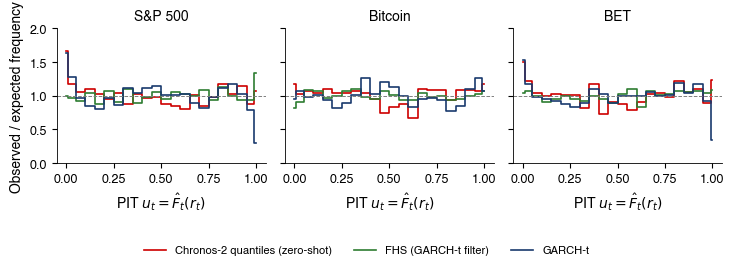

,mu,sigma,LR,p,tail_lo,tail_hi,p_chi2,QS
C2,-0.0352,1.0303,7.9681,0.0186,1.6710,1.0769,0.0037,0.5101
FHS,0.0130,0.9975,0.4842,0.7850,1.0026,1.0769,0.6967,0.5062
GARCH-t,-0.0426,0.9937,5.0874,0.0786,1.6339,0.2971,0.0000,0.5063


In [26]:
from scipy import optimize
def garch_grid(a, dates):
    """GARCH-t si FHS pe aceleasi origini ca in ch14_risk_*: PIT si grila de 21 de cuantile."""
    r = load_returns(a)
    x = r.values
    org = r.index.get_indexer(dates)
    gf, Z = garch_t(x, org)
    y = x[org]
    mu, s, nu = gf.mu.values, gf.sigma.values, gf.nu.values
    z = (y - mu) / s
    u_t = stats.t.cdf(z / np.sqrt((nu - 2) / nu), nu)
    q_t = mu[:, None] + s[:, None] * np.column_stack([t_std_q(nu, u) for u in LV])
    u_f = np.array([np.mean(Zi <= zi) for Zi, zi in zip(Z, z)])
    q_f = mu[:, None] + s[:, None] * np.stack([np.quantile(Zi, LV) for Zi in Z])
    return y, (u_t, q_t), (u_f, q_f)


def pit_grid(y, Q):
    """PIT prin interpolare liniara intre cuantilele grilei; NaN in afara [q_1%, q_99%] (cenzurat)."""
    u = np.full(len(y), np.nan)
    lo = y < Q[:, 0]
    hi = y > Q[:, -1]
    for i in np.where(~lo & ~hi)[0]:
        qi = np.maximum.accumulate(Q[i])
        u[i] = np.interp(y[i], qi, LV)
    return u, lo, hi


def berkowitz_cens(u, lo, hi):
    """LR pentru mu = 0, sigma = 1 in z = Phi^{-1}(u), cu cenzurare sub 1% si peste 99% (Berkowitz, 2001)."""
    cL, cH = stats.norm.ppf(0.01), stats.norm.ppf(0.99)
    z = stats.norm.ppf(np.clip(u[np.isfinite(u)], 1e-9, 1 - 1e-9))
    nL, nH = int(lo.sum()), int(hi.sum())

    def ll(p):
        m, s = p[0], np.exp(p[1])
        return (np.sum(stats.norm.logpdf(z, m, s)) + nL * stats.norm.logcdf((cL - m) / s)
                + nH * stats.norm.logsf((cH - m) / s))
    o = optimize.minimize(lambda p: -ll(p), [0.0, 0.0], method='Nelder-Mead')
    lr = 2 * (-o.fun - ll([0.0, 0.0]))
    return dict(mu=float(o.x[0]), sigma=float(np.exp(o.x[1])), LR=float(lr), p=float(stats.chi2.sf(lr, 2)),
                tail_lo=float(100 * lo.mean()), tail_hi=float(100 * hi.mean()))


def qscore(y, Q, idx=None):
    """Scorul cuantilic mediu pe grila (2/K) sum_k pinball_k: aproximarea CRPS pe grila de 21 de niveluri."""
    idx = np.arange(len(LV)) if idx is None else np.asarray(idx)
    s = np.zeros(len(y))
    for k in idx:
        s += 2 * (((y < Q[:, k]).astype(float) - LV[k]) * (Q[:, k] - y))
    return s / len(idx)


def bins_of(u, lo, hi):
    edges = np.r_[0, LV, 1]
    c = np.zeros(len(edges) - 1)
    c[0] += lo.sum()
    c[-1] += hi.sum()
    uu = u[np.isfinite(u)]
    k = np.clip(np.searchsorted(LV, uu, side='right'), 0, len(LV))
    for kk in k:
        c[kk] += 1
    return c, np.diff(edges)


def calibration():
    res, pits = {}, {}
    centre = [k for k, u in enumerate(LV) if 0.1 - 1e-9 <= u <= 0.9 + 1e-9]
    tails = [k for k, u in enumerate(LV) if u < 0.1 - 1e-9 or u > 0.9 + 1e-9]
    for a in ASSETS:
        d = load_csv(f'ch14_returns_{a}.csv')
        rk = load_csv(f'ch14_risk_{a}.csv')
        dates = rk.index
        d = d.loc[dates]
        Qc = d[[f'chronos2_q{u:.2f}' for u in LV]].values
        y, (u_t, Qt), (u_f, Qf) = garch_grid(a, dates)
        assert np.allclose(y, d['y'].values)
        # verificare: VaR 1% FHS din grila recalculata = cel din ch14_risk_*.csv
        assert np.allclose(-Qf[:, 0], rk['FHS|VaR1'].values, atol=1e-6)
        r = {}
        for nm, (uu, Q) in (('C2', (None, Qc)), ('GARCH-t', (u_t, Qt)), ('FHS', (u_f, Qf))):
            if uu is None:
                u, lo, hi = pit_grid(y, Q)
            else:
                lo, hi = uu < 0.01, uu > 0.99
                u = np.where(lo | hi, np.nan, uu)
            c, w = bins_of(u, lo, hi)
            chi = float(np.sum((c - len(y) * w) ** 2 / (len(y) * w)))
            bk = berkowitz_cens(u, lo, hi)
            qs, qc, qt = qscore(y, Q), qscore(y, Q, centre), qscore(y, Q, tails)
            r[nm] = dict(berk=bk, chi2=chi, p_chi2=float(stats.chi2.sf(chi, len(c) - 1)), qs=float(qs.mean()),
                         qs_c=float(qc.mean()), qs_t=float(qt.mean()),
                         dens=(c / (len(y) * w)).tolist(), _qs=qs, _qc=qc, _qt=qt)
        for nm in ('GARCH-t', 'FHS'):
            for s, key in (('_qs', 'dm'), ('_qc', 'dm_c'), ('_qt', 'dm_t')):
                dd = r['C2'][s] - r[nm][s]
                t = dd.mean() / nw_se(dd)
                r['C2'][f'{key}_{nm}'] = float(t)
                r['C2'][f'p{key}_{nm}'] = float(2 * stats.norm.sf(abs(t)))
        for nm in r:
            for s in ('_qs', '_qc', '_qt'):
                r[nm].pop(s)
        res[a] = r
        pits[a] = {nm: r[nm]['dens'] for nm in r}
        res[a]['n'] = int(len(y))
    OUT['calib'] = res
    # grafic: densitatea relativa a PIT pe intervalele grilei (1 = calibrare perfecta)
    fig, axs = plt.subplots(1, 3, figsize=(7.4, 2.5), sharey=True)
    edges = np.r_[0, LV, 1]
    hs = []
    for ax, a in zip(axs, ASSETS):
        for nm, col in (('C2', IDAred), ('FHS', Forest), ('GARCH-t', MainBlue)):
            v = np.r_[pits[a][nm], pits[a][nm][-1]]
            h, = ax.step(edges, v, where='post', color=col, lw=1.2)
            if a == 'sp500':
                hs.append(h)
        ax.axhline(1, color=Gray, lw=0.7, ls='--')
        ax.set_title(LABELS[a], color='black')
        ax.set_xlabel('PIT $u_t = \\hat F_t(r_t)$')
        ax.set_ylim(0, 2.0)
    axs[0].set_ylabel('Observed / expected frequency')
    fig_legend_bottom(fig, hs, ['Chronos-2 quantiles (zero-shot)', 'FHS (GARCH-t filter)', 'GARCH-t'], ncol=3,
                      y=0.04)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch14_pit')


LV = np.array(C2_LEVELS)
calibration()
pd.DataFrame({m: {**OUT['calib']['sp500'][m]['berk'], 'p_chi2': OUT['calib']['sp500'][m]['p_chi2'], 'QS': OUT['calib']['sp500'][m]['qs']} for m in ('C2', 'FHS', 'GARCH-t')}).T.round(4)

### B10. Conformal recalibration of Chronos-2 [Proposed]

- Adaptive conformal inference (250-day calibration window, gamma = 0.005) for the 1% and 2.5% quantiles; Kupiec, Christoffersen, DQ, FZ0. Models: B5, B9.

In [ ]:
# Your code here


### B11. A formal pre/post-release test [Proposed]

- Regress the QLIKE differential Chronos-2 minus log-HAR on a post-release dummy with Newey–West errors; minimum detectable effect. Model: B3.

In [ ]:
# Your code here


## Part C — can a zero-shot foundation model replace GARCH for the daily VaR 1% and ES 2.5% of the BET index? [Proposed]

- Compare HS, GARCH-t, FHS, raw Chronos-2 quantiles and FHS with foundation-model volatility.
- Combine coverage, independence, FZ0, the MCS, Basel zones and the window after 3 November 2025.

In [ ]:
# Your code here
